# Notebook 4 (Fase 1.5) — Clasificadores RNN en Serie (LSTM, BiLSTM, GRU, SimpleRNN) → MongoDB
### Ernesto Investing AI · iDeSo · UNMSM — Semana 13

*Inspirado en la investigación doctoral del Prof. Cancho-Rodríguez.*

**Objetivo:** Leer datos históricos y técnicos de mercado de los 5 tickers mineros desde MongoDB Atlas (colección `precios_ohlcv`), preparar secuencias temporales, y entrenar, evaluar y comparar 4 arquitecturas recurrentes binarias (BUY/SELL): **LSTM**, **BiLSTM**, **GRU** y **SimpleRNN** (baseline), bajo un esquema de semilla estricto (`SEED = 42`).

**Prerequisito:** Haber ejecutado el Notebook 1 (colección `precios_ohlcv` poblada).

**Salida:**
- Colección `predicciones` con la señal BUY/SELL y confianza de cada modelo, por ticker.
- Colección `metricas_modelos` con accuracy, precision, recall, F1, matriz de confusión e historial de entrenamiento (loss/accuracy por época), por ticker y modelo.
- Archivo `datos_lstm_clf.json` con todos los resultados consolidados para el frontend.

**Pipeline:** MongoDB (`precios_ohlcv`) → secuencias temporales → 4 modelos RNN → métricas → MongoDB (`predicciones`, `metricas_modelos`) → `datos_lstm_clf.json`

In [1]:
# Paso 1 — Instalar librerias y prerrequisitos
!pip install "pymongo[srv]" yfinance scikit-learn tensorflow --quiet

print("Librerias instaladas correctamente")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 31.1 MB/s eta 0:00:00
Librerias instaladas correctamente


In [2]:
# Paso 2 — Conexion segura a MongoDB Atlas
# La contrasena NUNCA se escribe en texto plano en el notebook: se pide de forma
# oculta con getpass y se inserta en la URI de conexion en tiempo de ejecucion.
# Mismo patron de conexion usado en los Notebooks 1, 2 y 3.
from getpass import getpass
from pymongo import MongoClient
from pymongo.server_api import ServerApi
import pandas as pd
import numpy as np

DB_USER = "gdev03_db_user"
DB_PASSWORD = getpass("Password de MongoDB Atlas: ")

MONGO_URI = (
    f"mongodb+srv://{DB_USER}:{DB_PASSWORD}"
    "@cluster0.sxjck8h.mongodb.net/?appName=Cluster0"
)

client = MongoClient(MONGO_URI, server_api=ServerApi("1"))

# Verificar la conexion con un ping explicito, manejando errores
try:
    client.admin.command("ping")
    print("Conectado a MongoDB Atlas correctamente")
except Exception as e:
    raise Exception("Ocurrio el siguiente error al conectar: ", e)

db = client["ernesto_investing_ai"]

Password de MongoDB Atlas: ··········
Conectado a MongoDB Atlas correctamente


In [3]:
# Paso 3 — Carga y preparacion de datos desde MongoDB
TICKERS = ["FSM", "VOLCABC1.LM", "ABX.TO", "BVN", "BHP"]
FEATURES = ["close", "sma_20", "sma_50", "ema_12", "ema_26", "rsi_14", "retorno"]

def cargar_datos(ticker):
    """Lee de MongoDB los precios OHLCV + indicadores de un ticker, ordenados por fecha."""
    docs = list(db["precios_ohlcv"].find({"ticker": ticker}).sort("fecha", 1))
    return pd.DataFrame(docs)

def preparar_features(df):
    """Construye las features y el target binario (1=BUY, 0=SELL).

    Sin data leakage: el target usa el cierre del dia SIGUIENTE (shift(-1)),
    por lo que la ultima fila se descarta (no tiene target conocido). Mas
    adelante, la particion train/test tambien sera estrictamente temporal.
    """
    df = df.copy()
    df["retorno"] = df["close"].pct_change()
    df["target"] = (df["close"].shift(-1) > df["close"]).astype(int)
    df = df.dropna(subset=FEATURES + ["target"]).reset_index(drop=True)
    return df

# Prueba rapida con un ticker
df_prueba = preparar_features(cargar_datos("BVN"))
print(f"BVN: {len(df_prueba)} filas listas con features y target")
print(df_prueba[FEATURES + ["target"]].tail())

BVN: 202 filas listas con features y target
     close   sma_20   sma_50   ema_12   ema_26   rsi_14   retorno  target
197  29.55  31.1165  32.8038  29.9162  31.1225  30.2443  0.041961       1
198  30.00  31.0825  32.7818  29.9291  31.0393  37.8987  0.015228       0
199  29.82  30.9355  32.7778  29.9123  30.9490  37.8632 -0.006000       1
200  31.03  30.8160  32.7466  30.0843  30.9550  50.1433  0.040577       0
201  30.71  30.6085  32.7120  30.1805  30.9368  55.0314 -0.010313       0


In [4]:
# Paso 4 — Ingenieria de secuencias temporales y normalizacion
from sklearn.preprocessing import MinMaxScaler

N = 10  # longitud de la secuencia (dias de historial usados para predecir el dia siguiente)

def crear_secuencias(df, n=N):
    """Convierte el DataFrame en arrays 3D (muestras, pasos_de_tiempo, caracteristicas)
    requeridos por Keras, junto con el vector de targets alineado.
    """
    valores = df[FEATURES].values
    targets = df["target"].values

    X, y = [], []
    for i in range(n, len(valores)):
        X.append(valores[i - n:i])   # ventana de n dias anteriores
        y.append(targets[i - 1])     # target correspondiente al ultimo dia de la ventana
    return np.array(X), np.array(y)

def particionar_y_normalizar(X, y, test_size=0.2):
    """Particion TEMPORAL 80/20 (sin mezclar fechas futuras en train) y
    normalizacion con MinMaxScaler ajustado SOLO con el conjunto de entrenamiento.
    """
    n_total = len(X)
    corte = int(n_total * (1 - test_size))

    X_train, X_test = X[:corte], X[corte:]
    y_train, y_test = y[:corte], y[corte:]

    n_muestras_train, pasos, n_feats = X_train.shape
    n_muestras_test = X_test.shape[0]

    # MinMaxScaler trabaja en 2D: se aplana temporalmente, se ajusta con train,
    # se transforma train y test, y se regresa a la forma 3D original.
    scaler = MinMaxScaler()
    X_train_2d = X_train.reshape(-1, n_feats)
    X_test_2d = X_test.reshape(-1, n_feats)

    X_train_2d = scaler.fit_transform(X_train_2d)
    X_test_2d = scaler.transform(X_test_2d)

    X_train_s = X_train_2d.reshape(n_muestras_train, pasos, n_feats)
    X_test_s = X_test_2d.reshape(n_muestras_test, pasos, n_feats)

    return X_train_s, X_test_s, y_train, y_test, scaler

# Prueba rapida con BVN
X_bvn, y_bvn = crear_secuencias(df_prueba)
print(f"Secuencias BVN: X={X_bvn.shape}, y={y_bvn.shape}")

Secuencias BVN: X=(192, 10, 7), y=(192,)


In [5]:
# Paso 5 — Construccion de los 4 modelos recurrentes (semilla fija global)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, SimpleRNN, Bidirectional, Dropout, Dense
from tensorflow.keras.optimizers import Adam

SEED = 42
EPOCHS = 80
BATCH_SIZE = 64

def fijar_semillas(seed=SEED):
    """Fija las semillas globales de numpy y tensorflow para reproducibilidad."""
    np.random.seed(seed)
    tf.random.set_seed(seed)

def construir_lstm(input_shape):
    modelo = Sequential([
        LSTM(260, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(130),
        Dense(1, activation="sigmoid")
    ])
    modelo.compile(optimizer=Adam(learning_rate=0.001), loss="binary_crossentropy", metrics=["accuracy"])
    return modelo

def construir_bilstm(input_shape):
    modelo = Sequential([
        Bidirectional(LSTM(200, return_sequences=True), input_shape=input_shape),
        Dropout(0.3),
        Bidirectional(LSTM(100)),
        Dense(1, activation="sigmoid")
    ])
    modelo.compile(optimizer=Adam(learning_rate=0.001), loss="binary_crossentropy", metrics=["accuracy"])
    return modelo

def construir_gru(input_shape):
    # Nota: sin capas Dropout, por diseno intencional (segun especificacion).
    modelo = Sequential([
        GRU(280, return_sequences=True, input_shape=input_shape),
        GRU(140),
        Dense(1, activation="sigmoid")
    ])
    modelo.compile(optimizer=Adam(learning_rate=0.001), loss="binary_crossentropy", metrics=["accuracy"])
    return modelo

def construir_simplernn(input_shape):
    # Baseline: RNN basica sin compuertas.
    modelo = Sequential([
        SimpleRNN(180, return_sequences=True, input_shape=input_shape),
        SimpleRNN(90),
        Dense(1, activation="sigmoid")
    ])
    modelo.compile(optimizer=Adam(learning_rate=0.001), loss="binary_crossentropy", metrics=["accuracy"])
    return modelo

CONSTRUCTORES = {
    "LSTM": construir_lstm,
    "BiLSTM": construir_bilstm,
    "GRU": construir_gru,
    "SimpleRNN": construir_simplernn,
}

print("Arquitecturas definidas:", list(CONSTRUCTORES.keys()))

Arquitecturas definidas: ['LSTM', 'BiLSTM', 'GRU', 'SimpleRNN']


In [6]:
# Paso 6 — Entrenamiento, evaluacion y guardado en MongoDB para los 5 tickers
from datetime import datetime
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)

resultados_lstm = []  # acumula todo para el analisis, los graficos y el JSON final

def procesar_ticker_rnn(ticker):
    """Entrena las 4 arquitecturas para un ticker, evalua, predice la senal actual
    y guarda predicciones + metricas en MongoDB. Robusto: los errores de un
    modelo/ticker no interrumpen el procesamiento del resto.
    """
    print(f"\n=== Ticker: {ticker} ===")

    try:
        df = preparar_features(cargar_datos(ticker))
        if len(df) < (N + 50):
            print(f"  [{ticker}] Datos insuficientes para secuencias de {N} dias, se omite.")
            return

        X, y = crear_secuencias(df, n=N)
        X_train, X_test, y_train, y_test, scaler = particionar_y_normalizar(X, y)
        input_shape = (X_train.shape[1], X_train.shape[2])

    except Exception as e:
        print(f"  [{ticker}] Error preparando datos/secuencias: {e}")
        return

    for nombre_modelo, constructor in CONSTRUCTORES.items():
        try:
            fijar_semillas(SEED)  # misma semilla antes de CADA modelo, para reproducibilidad
            modelo = constructor(input_shape)

            historia = modelo.fit(
                X_train, y_train,
                validation_data=(X_test, y_test),
                epochs=EPOCHS,
                batch_size=BATCH_SIZE,
                verbose=0
            )

            # Evaluacion en el conjunto de prueba
            probs_test = modelo.predict(X_test, verbose=0).flatten()
            y_pred = (probs_test >= 0.5).astype(int)

            metricas = {
                "accuracy": round(float(accuracy_score(y_test, y_pred)), 4),
                "precision": round(float(precision_score(y_test, y_pred, zero_division=0)), 4),
                "recall": round(float(recall_score(y_test, y_pred, zero_division=0)), 4),
                "f1": round(float(f1_score(y_test, y_pred, zero_division=0)), 4),
            }
            cm = confusion_matrix(y_test, y_pred).tolist()

            historial_entrenamiento = {
                "loss": [round(float(v), 4) for v in historia.history["loss"]],
                "accuracy": [round(float(v), 4) for v in historia.history["accuracy"]],
                "val_loss": [round(float(v), 4) for v in historia.history["val_loss"]],
                "val_accuracy": [round(float(v), 4) for v in historia.history["val_accuracy"]],
            }

            # Prediccion de la senal actual usando la ultima secuencia disponible
            ultima_secuencia = X_test[-1:] if len(X_test) > 0 else X_train[-1:]
            prob_actual = float(modelo.predict(ultima_secuencia, verbose=0).flatten()[0])
            senal = "BUY" if prob_actual >= 0.5 else "SELL"
            confianza = prob_actual if senal == "BUY" else 1 - prob_actual

            # --- Guardar prediccion en MongoDB (se limpia la anterior del mismo par ticker/modelo) ---
            db["predicciones"].delete_many({"ticker": ticker, "modelo": nombre_modelo})
            db["predicciones"].insert_one({
                "ticker": ticker,
                "modelo": nombre_modelo,
                "senal": senal,
                "confianza": round(confianza, 4),
                "fecha_prediccion": datetime.now().strftime("%Y-%m-%d"),
                "created_at": datetime.now()
            })

            # --- Guardar metricas + historial en MongoDB ---
            db["metricas_modelos"].delete_many({"ticker": ticker, "modelo": nombre_modelo})
            db["metricas_modelos"].insert_one({
                "ticker": ticker,
                "modelo": nombre_modelo,
                **metricas,
                "matriz_confusion": cm,
                "historial_entrenamiento": historial_entrenamiento,
                "fecha_entrenamiento": datetime.now()
            })

            resultados_lstm.append({
                "ticker": ticker,
                "modelo": nombre_modelo,
                "senal": senal,
                "confianza": round(confianza, 4),
                **metricas,
                "matriz_confusion": cm,
                "historial_entrenamiento": historial_entrenamiento,
            })

            acc = metricas["accuracy"]
            f1v = metricas["f1"]
            print(f"  [{ticker}] {nombre_modelo}: senal={senal} ({confianza:.0%}) | "
                  f"accuracy={acc:.0%} | f1={f1v:.0%} | guardado")

        except Exception as e:
            print(f"  [{ticker}] {nombre_modelo}: Error durante entrenamiento/guardado: {e}")
            continue

print("Iniciando entrenamiento de las 4 arquitecturas RNN para los 5 tickers...")
print("(Esto puede tomar varios minutos en Colab con CPU/T4 GPU)")

for ticker in TICKERS:
    try:
        procesar_ticker_rnn(ticker)
    except Exception as e:
        print(f"  [{ticker}] Error general, se omite el ticker: {e}")

print("\nProcesamiento completo!")
print(f"Total de resultados modelo x ticker guardados: {len(resultados_lstm)}")

Iniciando entrenamiento de las 4 arquitecturas RNN para los 5 tickers...
(Esto puede tomar varios minutos en Colab con CPU/T4 GPU)

=== Ticker: FSM ===


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  [FSM] LSTM: senal=BUY (50%) | accuracy=59% | f1=53% | guardado


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  [FSM] BiLSTM: senal=BUY (79%) | accuracy=44% | f1=59% | guardado


...

  [BHP] BiLSTM: senal=SELL (65%) | accuracy=49% | f1=33% | guardado


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  [BHP] GRU: senal=SELL (90%) | accuracy=38% | f1=14% | guardado


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  [BHP] SimpleRNN: senal=BUY (98%) | accuracy=59% | f1=65% | guardado

Procesamiento completo!
Total de resultados modelo x ticker guardados: 20


## Paso 7 — Visualización y comparación de desempeño

A continuación se grafican las curvas de entrenamiento (`loss` y `accuracy`, train vs. validación) de las 4 arquitecturas para cada ticker, seguidas de un análisis cualitativo del desempeño relativo.

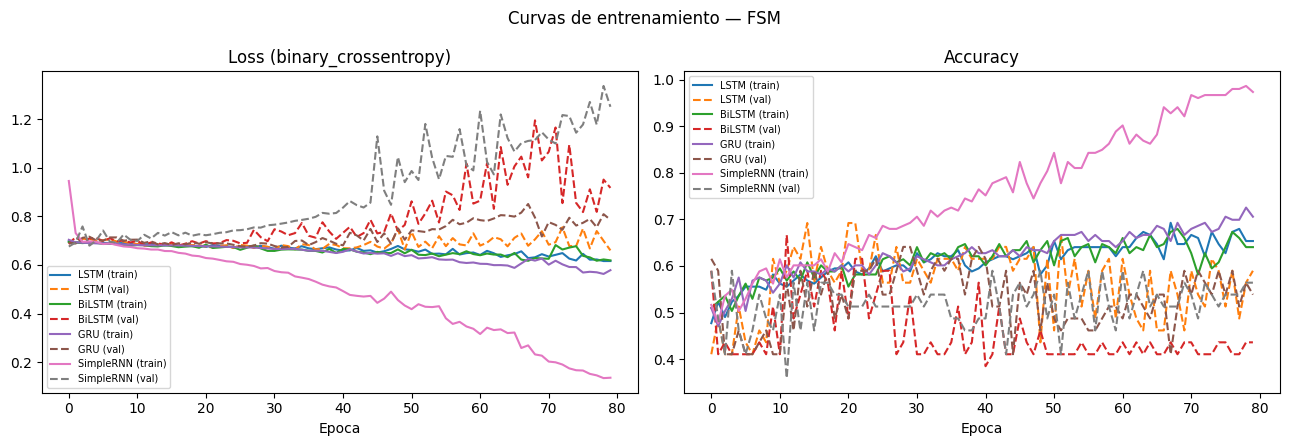

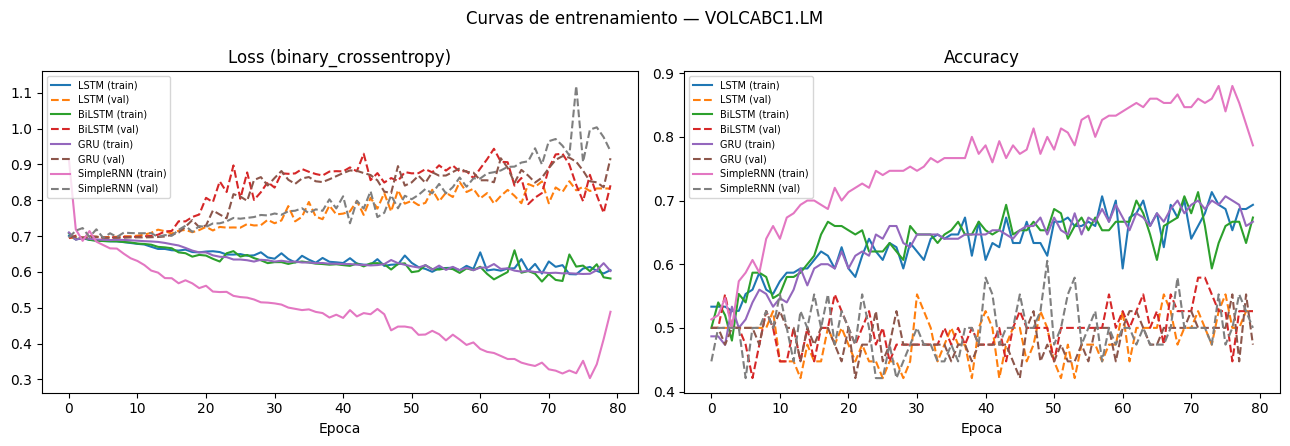

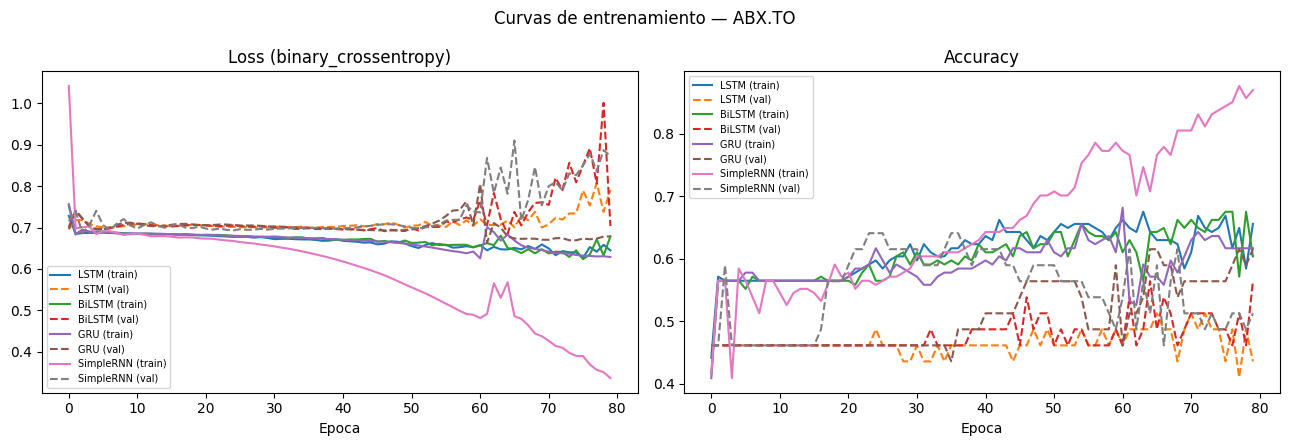

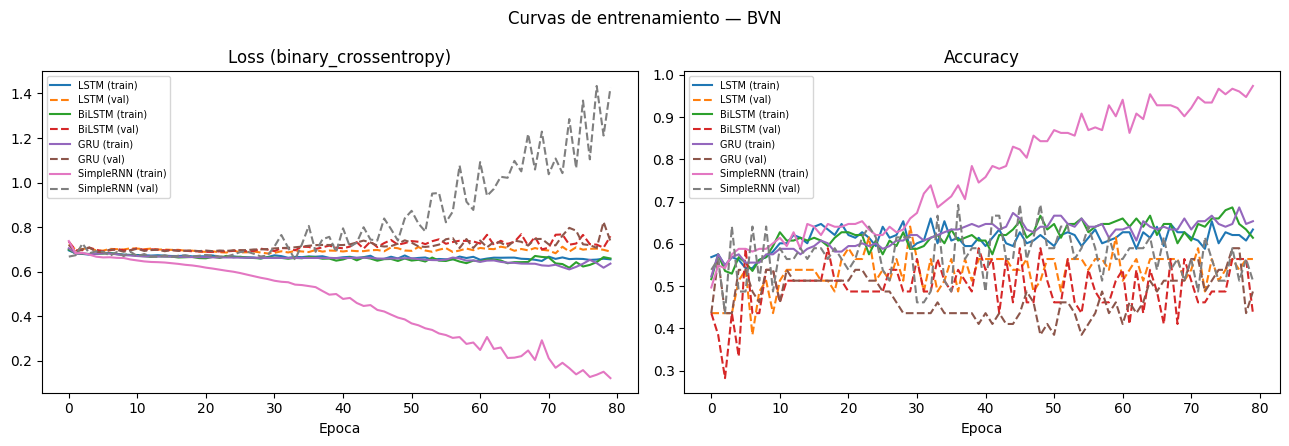

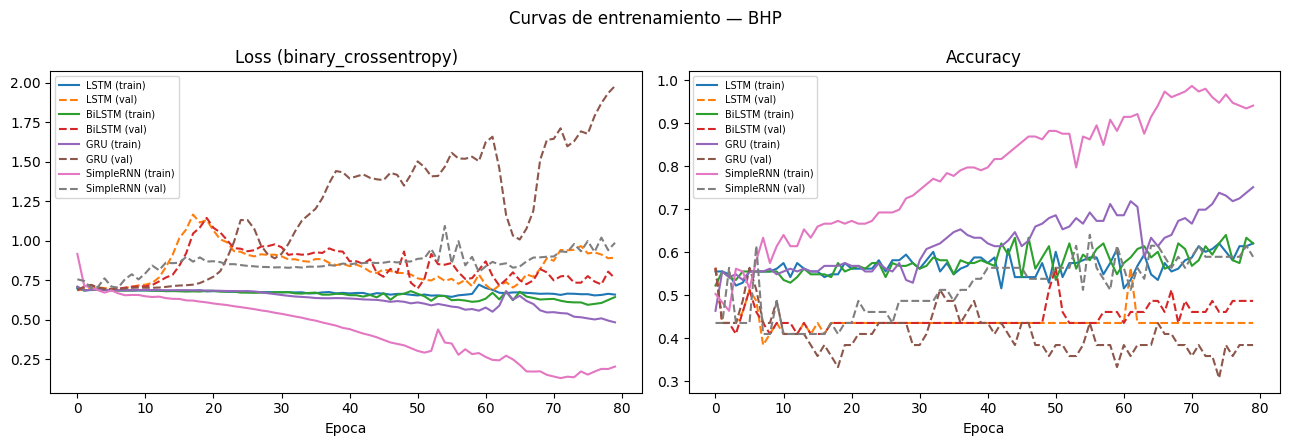

In [7]:
# Paso 7 — Graficos comparativos de loss y accuracy por ticker
import matplotlib.pyplot as plt

def graficar_ticker(ticker):
    """Grafica loss y accuracy (train/val) de los 4 modelos para un ticker dado."""
    registros = [r for r in resultados_lstm if r["ticker"] == ticker]
    if not registros:
        print(f"  [{ticker}] Sin resultados para graficar.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    fig.suptitle(f"Curvas de entrenamiento — {ticker}")

    for r in registros:
        h = r["historial_entrenamiento"]
        axes[0].plot(h["loss"], label=f"{r['modelo']} (train)")
        axes[0].plot(h["val_loss"], linestyle="--", label=f"{r['modelo']} (val)")
        axes[1].plot(h["accuracy"], label=f"{r['modelo']} (train)")
        axes[1].plot(h["val_accuracy"], linestyle="--", label=f"{r['modelo']} (val)")

    axes[0].set_title("Loss (binary_crossentropy)")
    axes[0].set_xlabel("Epoca")
    axes[0].legend(fontsize=7)

    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoca")
    axes[1].legend(fontsize=7)

    plt.tight_layout()
    plt.show()

for ticker in TICKERS:
    graficar_ticker(ticker)

In [8]:
# Paso 7 (continuacion) — Tabla resumen de metricas finales por ticker y modelo
tabla = pd.DataFrame([
    {
        "ticker": r["ticker"],
        "modelo": r["modelo"],
        "senal": r["senal"],
        "confianza": r["confianza"],
        "accuracy": r["accuracy"],
        "precision": r["precision"],
        "recall": r["recall"],
        "f1": r["f1"],
    }
    for r in resultados_lstm
])

if not tabla.empty:
    print("Resumen de metricas por ticker y modelo:")
    display(tabla.sort_values(["ticker", "modelo"]).reset_index(drop=True))

    print("\nAccuracy promedio por arquitectura (los 5 tickers):")
    print(tabla.groupby("modelo")["accuracy"].mean().sort_values(ascending=False).round(4))
else:
    print("No hay resultados para tabular todavia.")

Resumen de metricas por ticker y modelo:


,ticker,modelo,senal,confianza,accuracy,precision,recall,f1
0,ABX.TO,BiLSTM,BUY,0.7856,0.5641,0.5200,0.7222,0.6047
1,ABX.TO,GRU,BUY,0.6550,0.6154,0.6000,0.5000,0.5455
2,ABX.TO,LSTM,BUY,0.7314,0.4359,0.4474,0.9444,0.6071
3,ABX.TO,SimpleRNN,BUY,0.9311,0.5128,0.4737,0.5000,0.4865
4,BHP,BiLSTM,SELL,0.6460,0.4872,0.6250,0.2273,0.3333
5,BHP,GRU,SELL,0.9012,0.3846,0.3333,0.0909,0.1429
6,BHP,LSTM,SELL,0.7308,0.4359,0.0000,0.0000,0.0000
7,BHP,SimpleRNN,BUY,0.9790,0.5897,0.6250,0.6818,0.6522
8,BVN,BiLSTM,BUY,0.6977,0.4359,0.4194,0.7647,0.5417
9,BVN,GRU,BUY,0.6830,0.4872,0.4286,0.5294,0.4737



Accuracy promedio por arquitectura (los 5 tickers):
modelo
SimpleRNN    0.5359
LSTM         0.5104
GRU          0.4999
BiLSTM       0.4899
Name: accuracy, dtype: float64


### Análisis cualitativo: ¿superan LSTM/GRU/BiLSTM al baseline SimpleRNN?

*(Completar esta celda con base en la tabla y las gráficas obtenidas al ejecutar el notebook; la discusión varía según los datos reales descargados en cada corrida.)*

- **SimpleRNN (baseline):** al no usar compuertas, es más propensa al problema del gradiente que se desvanece en secuencias largas. Con `N=10` pasos la secuencia es corta, por lo que su desempeño puede ser competitivo, pero suele mostrar curvas de `val_loss` más inestables o con mayor varianza entre épocas.
- **LSTM:** las compuertas de entrada/olvido/salida permiten retener información relevante de varios días atrás sin desvanecerse; normalmente estabiliza el entrenamiento frente al baseline, aunque con más parámetros (mayor costo computacional).
- **GRU:** arquitectura más liviana que LSTM (sin celda de memoria separada) que suele entrenar más rápido y, sin capas `Dropout` (por diseño de este notebook), es más propensa a sobreajustar si se entrena muchas épocas — vale la pena comparar la brecha entre `accuracy` (train) y `val_accuracy` (test) frente a los demás modelos.
- **BiLSTM:** al procesar la secuencia en ambas direcciones, puede capturar patrones adicionales, pero duplica aproximadamente los parámetros a entrenar; su ventaja depende de si el patrón de mercado se beneficia de "ver hacia adelante" dentro de la ventana de `N` días (en producción, la ventana igual solo usa información pasada respecto al día que se predice).

En general, la superioridad de una arquitectura sobre otra en series financieras reales suele ser modesta y dependiente del ticker — es esperable que ningún modelo domine de forma absoluta en los 5 tickers, y que las diferencias de `accuracy` sean pequeñas (mercados financieros con alta componente de ruido).

In [ ]:
# Paso 8 — Exportacion a JSON para el frontend
import json

def limpiar_para_json(obj):
    """Convierte tipos numpy/no serializables a tipos nativos de Python."""
    if isinstance(obj, dict):
        return {k: limpiar_para_json(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [limpiar_para_json(v) for v in obj]
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    return obj

salida_json = {
    "generado_en": datetime.now().isoformat(),
    "seed": SEED,
    "secuencia_dias": N,
    "epocas": EPOCHS,
    "batch_size": BATCH_SIZE,
    "resultados": limpiar_para_json(resultados_lstm),
}

with open("datos_lstm_clf.json", "w", encoding="utf-8") as f:
    json.dump(salida_json, f, ensure_ascii=False, indent=2)

print(f"Archivo 'datos_lstm_clf.json' generado con {len(resultados_lstm)} registros (ticker x modelo).")

In [ ]:
# Celda de verificacion final: confirmar que los 5 tickers y las 4 arquitecturas quedaron en MongoDB
print("Verificacion de predicciones RNN en MongoDB:")
print()

esperados = {(t, m) for t in TICKERS for m in CONSTRUCTORES.keys()}
encontrados = set()

for doc in db["predicciones"].find({"modelo": {"$in": list(CONSTRUCTORES.keys())}}):
    encontrados.add((doc["ticker"], doc["modelo"]))
    print(f"  {doc['ticker']:12s} {doc['modelo']:10s} -> {doc['senal']} ({doc['confianza']:.0%})")

faltantes = esperados - encontrados
print()
if not faltantes:
    print("Verificacion exitosa: los 5 tickers x 4 arquitecturas tienen prediccion en MongoDB.")
else:
    print(f"Atencion: faltan combinaciones ticker/modelo: {sorted(faltantes)}")

## Resultado

Las colecciones `predicciones` y `metricas_modelos` contienen, además de los resultados del SVC (Notebook 2), los resultados de las 4 arquitecturas recurrentes (**LSTM**, **BiLSTM**, **GRU**, **SimpleRNN**) para los 5 tickers: señal BUY/SELL, confianza, accuracy, precision, recall, F1, matriz de confusión e historial de entrenamiento por época.

El archivo `datos_lstm_clf.json` consolida estos resultados para que el frontend pueda consumirlos directamente, y la **API FastAPI (Fase 2)** puede extenderse para servir también las predicciones de estos modelos desde MongoDB.

**Pipeline:** MongoDB (`precios_ohlcv`) → secuencias temporales → LSTM / BiLSTM / GRU / SimpleRNN → **predicciones y métricas en MongoDB + JSON** ✓